# Objectif 

L'objectif de ce notebook est d'étudier l'influence des paramètres d'un train de LFM sur l'estimation des RTFs.


En particulier, on s'intéresse à la propagation dans un canal de propagation dons les paramètres sont ajustés pour réduire la durée de la réponse impulsionnelle et ainsi réduire la taille des fenêtres utilisées pour le calcul des matrices de covariances et donc pour le calcul du vecteur de RTF. 

L'environnement considéré est un guide d'onde de Pekeris dont les paramètres sont les suivants : 

* Dans la colonne d'eau :
    * $c_0 = 1500 m/s$
    * $\rho_0 = 1000 kg/m^3$
* Dans le sédiment : 
    * $c_1 = 1600 m/s$
    * $\rho_1 = 1500 kg/m^3$
    * $\alpha_1 = 0.2 dB/\lambda$

Références : 
* Bologni, G., Hendriks, R. C., & Heusdens, R. (2025). Wideband Relative Transfer Function (RTF) Estimation Exploiting Frequency Correlations. IEEE Transactions on Audio, Speech and Language Processing, 33, 731–747. https://doi.org/10.1109/TASLPRO.2025.3533371
* Napolitano, A. (2020). A - Nonstationary signal analysis. In A. Napolitano (Ed.), Cyclostationary Processes and Time Series (pp. 471–478). Academic Press. https://doi.org/https://doi.org/10.1016/B978-0-08-102708-0.00028-5


In [1]:
import os
import sys
import time
import numpy as np
import xarray as xr
import scipy.signal as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

# Load usefull functions
from signals.AcousticComponent import AcousticSource
from source.signal_generator import SignalGenerator
from source.rtf_estimator import RTFEstimator

import source.global_constants as g
from publication.publication_figure import PubFigure, LargeFigure, SmallFigure
from misc import mult_along_axis, cast_matrix_to_target_shape
from propa.rtf.rtf_utils import D_hermitian_angle_fast

pfig = PubFigure()
language = "fr" 

In [2]:
name = "pekeris_short_ir_waveguide"

root =r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_estimation"
folder_root = os.path.join(root, name)
tc_root_dir = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\kraken_toolbox\testcases"
)
img_folder_path = os.path.join(folder_root, "img")
data_folder_path = os.path.join(folder_root, "data")

# tf_fpath = os.path.join(data_folder_path, "tf_perf.nc")
tf_fpath = os.path.join(data_folder_path, "tf_hla.nc")

ir_fpath = os.path.join(data_folder_path, "ir.nc")

In [3]:
sg = SignalGenerator()

# Build testcase informations

In [4]:
hla_rtf_fpath = os.path.join(data_folder_path, f"hla_rtf.nc")

In [5]:
testcase_infos = {}
sig_names = ["white_noise", "chirp_lfm"]
n_tests = len(sig_names)
for i_tc, sig_name in enumerate(sig_names):
    testcase_infos[i_tc] = {
        "name": sig_name,
        "sig_fpath": os.path.join(data_folder_path, f"sig_{sig_name}.nc"),
        "hla_sig_fpath": os.path.join(data_folder_path, f"hla_sig_{sig_name}.nc"),
    }

    print(f"Testcase {i_tc}: ")
    print(testcase_infos[i_tc])

Testcase 0: 
{'name': 'white_noise', 'sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\sig_white_noise.nc', 'hla_sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\hla_sig_white_noise.nc'}
Testcase 1: 
{'name': 'chirp_lfm', 'sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\sig_chirp_lfm.nc', 'hla_sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\hla_sig_chirp_lfm.nc'}


# Introduce useful functions

In [6]:
def propagate_sig(tf_xr, src, rcv_range, rcv_depth, apply_grid_delay=False, tau=None, grid_ranges_from_rcv=None):
    """
    Propagate the source signal using the transfer function dataset.
    """

    # Slice required transfer function
    tf_xr = tf_xr.sel(r=rcv_range, z=rcv_depth, method="nearest")

    # Source spectrum
    Sf = src.positive_spectrum
    fmin = np.min(tf_xr.f.values)
    idx_first_freq = np.argmin(np.abs(src.positive_freq - fmin))
    Sf = Sf[idx_first_freq:]

    tf = tf_xr.tf_real + 1j * tf_xr.tf_imag  # (nf, nz, nr)

    # Derive received spectrum (Y = SH)
    k0 = 2 * np.pi * tf_xr.f.values / g.c0
    norm_factor = np.exp(1j * k0) / (4 * np.pi)

    # Derive delay to apply
    if not apply_grid_delay:
        if tau is not None:
            tau_rcv = tau
        else:
            tau_rcv = tf_xr.r.min().values / g.c0

        # Derive delay factor to take into account the propagation time
        delay_rcv = np.exp(1j * 2 * np.pi * tau_rcv * tf_xr.f.values)  # (nf,)

        # Propagated spectrum
        y_f = mult_along_axis(tf, Sf * norm_factor * delay_rcv, axis=0)

    else:
        if grid_ranges_from_rcv is None:
            raise ValueError("grid_ranges_from_rcv must be provided if apply_grid_delay is True")
        else: 

            # Derive delay for each receiver
            delay_rcv = (
                grid_ranges_from_rcv / g.c0
            )  # (nz, nr, nrcv)

            # Same delay is applied to each receiver : the receiver with the minimum delay is taken as the time reference
            # (we are only interested in relative time difference)
            tau = np.min(delay_rcv, axis=-1)  # (nz, nr) # TODO update comment

            # Aplly small offset to avoid wrapping a small part of the signal around
            # tau_offset = 0.2
            # tau = tau - tau_offset
            tau *= 0.99

            # Cast tau gridded tf shape
            tau_mat = cast_matrix_to_target_shape(
                tau, tf_xr.tf_real.shape
            )  # (nf, nz, nr)

            tau_mat = mult_along_axis(tau_mat, tf_xr.f.values, axis=0)
            delay_rcv = np.exp(1j * 2 * np.pi * tau_mat)

            # Propagated spectrum
            y_f = mult_along_axis(tf, Sf * norm_factor, axis=0)
            y_f *= delay_rcv  # (nf, nz, nr)


    # Pad with zeros to get the full spectrum
    n_pos_freq = src.positive_freq.shape[0]
    nfreq = y_f.shape[0]
    missing_freq = n_pos_freq - nfreq
    if missing_freq > 0:
        y_f = np.pad(y_f, ((missing_freq, 0), (0, 0), (0, 0)), mode="constant")
    # tau_rcv = target_range / g.c0

    nfft_inv = (
        4 * src.nfft
    )  # according to Jensen et al. (2000) p.616 : dt < 1 / (8 * fmax) for visual inspection of the propagated pulse
    T_tot = 1 / src.df
    dt = T_tot / nfft_inv
    t = np.arange(0, T_tot, dt)

    # FFT inv to get signal
    y_t = np.fft.irfft(y_f, axis=0, n=nfft_inv)  # (nt, nz, nr)
    y_t = np.real(y_t)  # Keep only real part

    sig_xr = xr.Dataset(
        coords=dict(
            t=t,
            z=tf_xr.z,
            r=tf_xr.r,
        ),
        data_vars=dict(
            s=(["t", "z", "r"], y_t),
        )
    )

    return t, y_t, sig_xr

In [7]:
def build_hla_features(
    tf_xr, src, delta_r_rcv, rcv_range, rcv_depth, n_rcv, rmin=None, rmax=None, z_src=999
):
    # Slice the transfer function dataset to the required range and depth
    tf_xr = tf_xr.sel(r=rcv_range, z=rcv_depth, method="nearest")

    if rmin is None or rmax is None:
        # Define rmin and rmax
        rmin_tf = tf_xr.r.min().values
        rmax_tf = tf_xr.r.max().values
        rmin = rmin_tf + (n_rcv - 1) * delta_r_rcv
        rmax = rmax_tf

    # Reference transfert function
    tf_rcv_ref = (
        tf_xr.sel(r=slice(rmin, rmax)).tf_real
        + 1j * tf_xr.sel(r=slice(rmin, rmax)).tf_imag
    )

    # Derive distance to rcv for delay calculation
    grid_ranges_from_rcv = np.zeros((len(tf_rcv_ref.z), len(tf_rcv_ref.r), n_rcv))
    for i in range(0, n_rcv):
        delta_r = i * delta_r_rcv
        rr, zz = np.meshgrid(tf_rcv_ref.r.values - delta_r, tf_rcv_ref.z.values)
        d2 = rr**2 + (z_src - zz) ** 2
        grid_ranges_from_rcv[:, :, i] = np.sqrt(d2)

    # tau_rcv_min = (rmin - (n_rcv - 1) * delta_r_rcv) / g.c0

    # Initialize the grid
    grid_shape = tf_rcv_ref.shape + (n_rcv,)
    # hla_sig = np.zeros(grid_shape, dtype=np.float64)
    hla_rtf = np.zeros(grid_shape, dtype=np.complex128)

    for i in range(0, n_rcv):
        # Receiver range displacement from the reference position
        delta_r = i * delta_r_rcv
        r_min_i = rmin - delta_r
        r_max_i = rmax - delta_r
        # Slice the dataset corresponding to the current receiver position
        xr_tf_rcv_i = tf_xr.sel(r=slice(r_min_i, r_max_i+1))        # +1 to include the last point

        ## Signal ##
        t, y_t, sig_xr = propagate_sig(
            xr_tf_rcv_i,
            src,
            rcv_range=xr_tf_rcv_i.r.values,
            rcv_depth=xr_tf_rcv_i.z.values,
            apply_grid_delay=True,
            grid_ranges_from_rcv=grid_ranges_from_rcv,
        )
        # Store the signal
        if i == 0:
            # Initialize the signal array with the first signal
            sig_shape = sig_xr.s.shape + (n_rcv,)
            hla_sig = np.zeros(
                sig_shape,
                dtype=np.float64,
            )
        hla_sig[..., i] = sig_xr.s.values

        ## RTF ##
        tf_rcv_i = xr_tf_rcv_i.tf_real + 1j * xr_tf_rcv_i.tf_imag
        # Compute the RTF
        rtf_i = tf_rcv_i.values / tf_rcv_ref
        # Store the RTF
        hla_rtf[..., i] = rtf_i.values

    # Convert to xarrays for easy manipulation
    r = tf_rcv_ref.r.values
    z = tf_rcv_ref.z.values
    f = tf_rcv_ref.f.values

    # Signal
    hla_sig_xr = xr.Dataset(
        coords=dict(
            t=t,
            z=z,
            r=r,
            idx_rcv=np.arange(n_rcv),
        ),
        data_vars=dict(
            s=(["t", "z", "r", "idx_rcv"], hla_sig),
        )
    ) 

    # RTF
    hla_rtf_grid = xr.Dataset(
        coords=dict(
            f=f,
            z=z,
            r=r,
            idx_rcv=np.arange(n_rcv),
        ),
        data_vars=dict(
            rtf_real=(["f", "z", "r", "idx_rcv"], np.real(hla_rtf)),
            rtf_imag=(["f", "z", "r", "idx_rcv"], np.imag(hla_rtf)),
        )
    )

    return hla_sig_xr, hla_rtf_grid

In [8]:
def generate_noise(z_xr, snr, idx_rcv_ref=0):
    """ Generate noise to add to the signal. """
    # Build noise
    sigma_rcv_ref = np.std(z_xr.sel(idx_rcv=idx_rcv_ref))
    # Normalize to account for the reference signal power to reach required snr at receiver n°0
    sigma = sigma_rcv_ref * np.sqrt(10 ** (-snr / 10))
    # Noise
    noise = np.random.normal(loc=0, scale=sigma, size=z_xr.shape)    # Noise to estimate noise covariance matrix 
    noise_mix = np.random.normal(loc=0, scale=sigma, size=z_xr.shape)    # Noise to add to signal 

    return noise, noise_mix

## Load transfer function dataset 

In [9]:
# Load transfer functions from netcdf
ds_tf = xr.open_dataset(tf_fpath)

In [10]:
# Extract usefull information from the dataset
src_fs = ds_tf.attrs["fs"]
src_signal_duration = ds_tf.attrs["signal_duration"]
depth = ds_tf.attrs["waveguide_depth"]
src_depth = ds_tf.attrs["src_depth"]        # Because of reciprocity this actually represents the HLA receiver depth

### Définition des paramètres d'étude

In [11]:
idx_rcv_ref = 0

r_plot = 30 * 1e3
z_plot = 5

# Position where rtf are estimated
r_hat = 30 * 1e3
z_hat = 5

hla_delta_r_rcv = 700  # Receiver range step in meters
hla_nrcv = 5  # Number of receivers in the HLA

# Subsample transfer function dataset to reduce memory usage
# rcv_rmin = ds_tf.r.min().values
rcv_rmin = r_hat - (hla_nrcv + 1) * hla_delta_r_rcv
rcv_rmax = ds_tf.r.max().values
rcv_dr = 100
rcv_range = np.arange(rcv_rmin, rcv_rmax + rcv_dr, rcv_dr)

# rcv_zmin = ds_tf.z.min().values
rcv_zmin = 5
rcv_zmax = np.max([50, z_hat, z_plot])
rcv_dz = 10
rcv_depth = np.arange(rcv_zmin, rcv_zmax + rcv_dz, rcv_dz)

## Plot transfer function


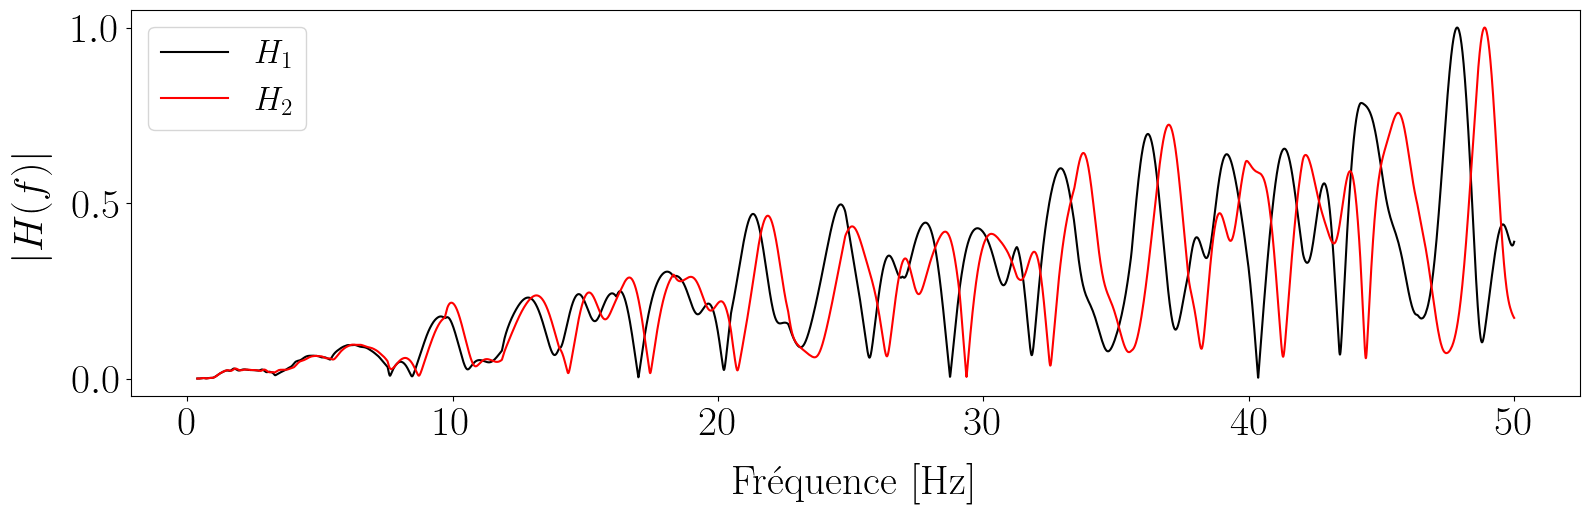

In [12]:
lfig = LargeFigure(language=language, legend_fontsize=24)
plt.figure()

colors=["k", "r", "b"] 
nrcv_plot = 2
for i in range(nrcv_plot):
    r_rcv_plot = r_hat + i * hla_delta_r_rcv
    tf_rcv = (
        ds_tf.sel(r=r_rcv_plot, z=z_plot, method="nearest").tf_real
        + 1j * ds_tf.sel(r=r_rcv_plot, z=z_plot, method="nearest").tf_imag
    )
    tf_pos_mod = np.abs(tf_rcv) / np.max(np.abs(tf_rcv))

    tf_pos_mod.plot(x="f", label=rf"$H_{i+1}$", color=colors[i])
plt.title("")
lfig.f_label.set_axis_label("x")
lfig.tfmod_label.set_axis_label("y")
plt.legend()

# Save figure
fpath = os.path.join(img_folder_path, f"tf_hla_r12.pdf")
plt.savefig(fpath, dpi=300)

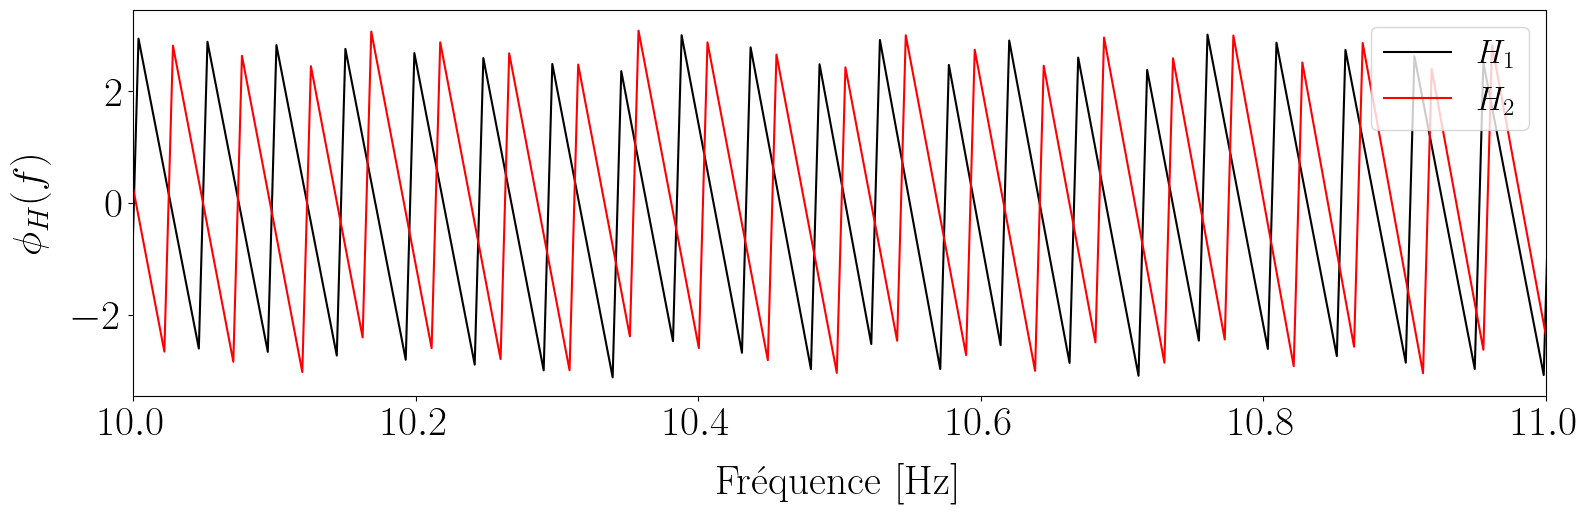

In [13]:
plt.figure()

colors = ["k", "r", "b"]
nrcv_plot = 2
for i in range(nrcv_plot):
    r_rcv_plot = r_hat + i * hla_delta_r_rcv
    tf_rcv = (
        ds_tf.sel(r=r_rcv_plot, z=z_plot, method="nearest").tf_real
        + 1j * ds_tf.sel(r=r_rcv_plot, z=z_plot, method="nearest").tf_imag
    )
    tf_phase = np.angle(tf_rcv)
    plt.plot(tf_rcv.f.values, tf_phase, label=rf"$H_{i+1}$", color=colors[i])

plt.title("")
lfig.f_label.set_axis_label("x")
lfig.tfphase_label.set_axis_label("y")
plt.legend()
plt.xlim([10, 11])

# Save figure
fpath = os.path.join(img_folder_path, f"tf_phase_hla_r12.pdf")
plt.savefig(fpath, dpi=300)

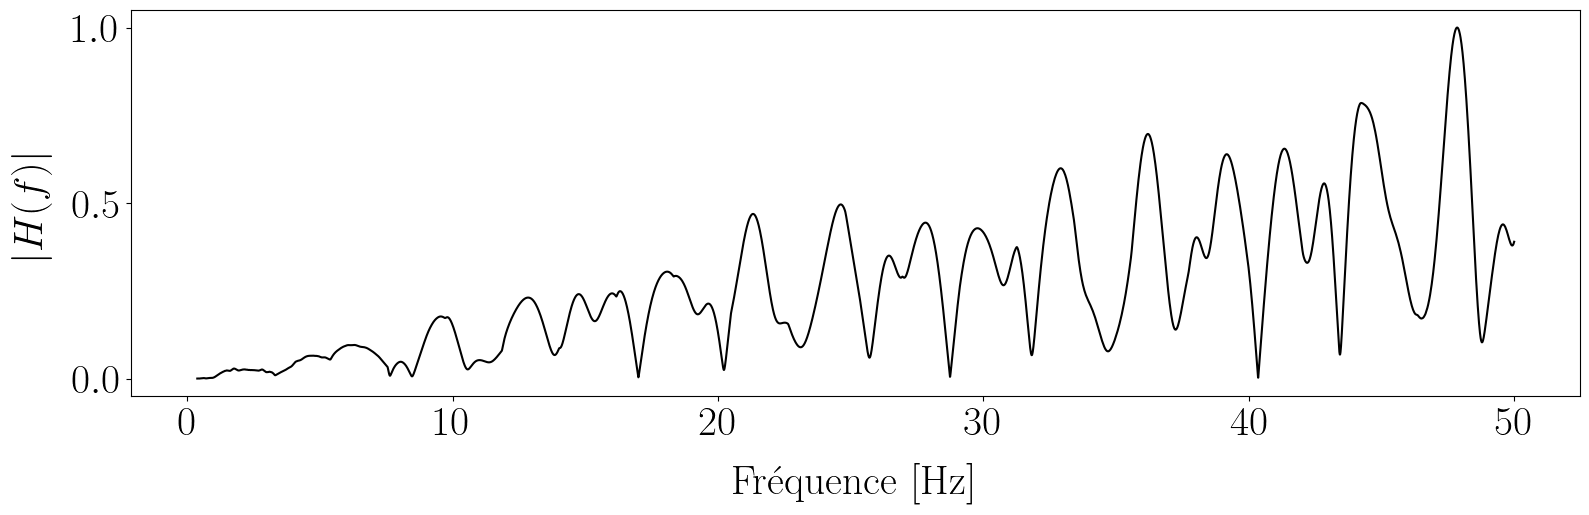

In [14]:
tf_pos = ds_tf.sel(r=r_plot, z=z_plot, method="nearest").tf_real + 1j * ds_tf.sel(r=r_plot, z=z_plot, method="nearest").tf_imag

k0 = 2 * np.pi * ds_tf.f.values / g.c0
norm_factor = np.exp(1j * k0) / (4 * np.pi)
tf_pos *= norm_factor


tf_pos_mod = np.abs(tf_pos) / np.max(np.abs(tf_pos))

lfig = LargeFigure(language=language)
plt.figure()
tf_pos_mod.plot(x="f", color="k")
plt.title("")
lfig.f_label.set_axis_label("x")
lfig.tfmod_label.set_axis_label("y")

# Save figure*
fpath = os.path.join(img_folder_path, f"tf_r{r_plot*1e-3:.0f}km_z{z_plot:.0f}m.pdf")
plt.savefig(fpath, dpi=300)


# Génération des jeux de données pour chacun des cas test 

## Cas test 1 : bruit blanc 

In [15]:
# Extract testcase info
i_tc = 1
sig_name = testcase_infos[i_tc]["name"]
sig_fpath = testcase_infos[i_tc]["sig_fpath"]
hla_sig_fpath = testcase_infos[i_tc]["hla_sig_fpath"]

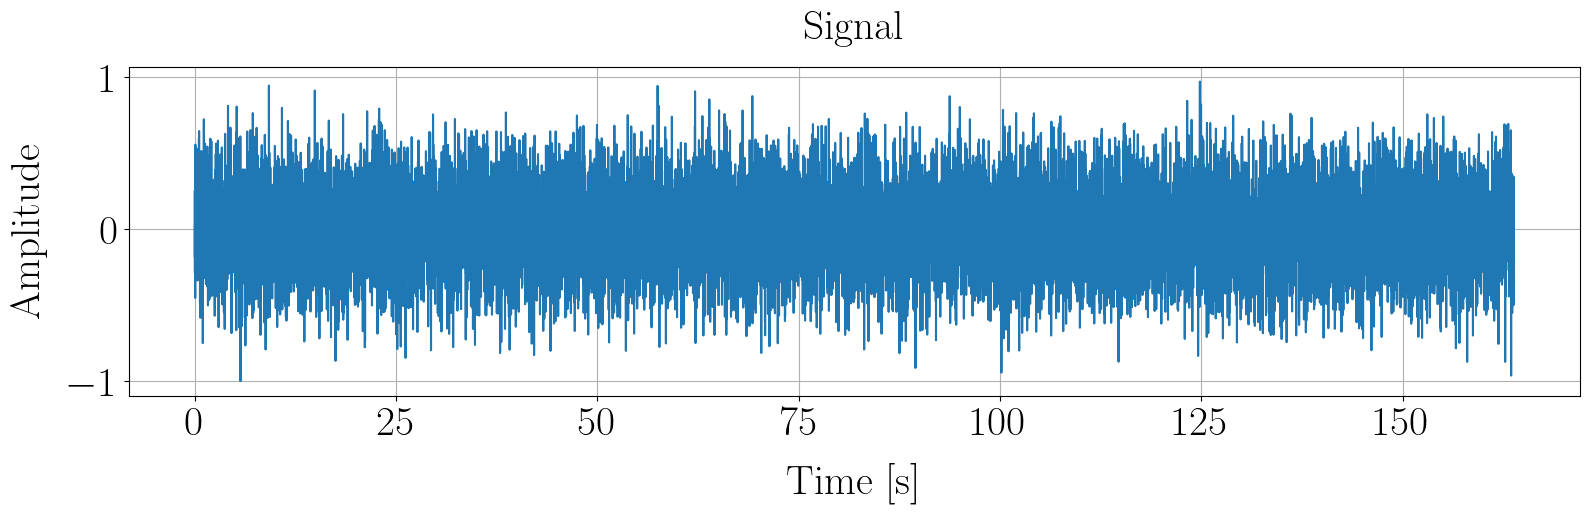

In [16]:
# Define source signal
t, s = sg.colored_noise(T=src_signal_duration, fs=src_fs, noise_color="white")
# t, s = sg.colored_noise(T=2000, fs=src_fs, noise_color="white")

s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="White noise",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

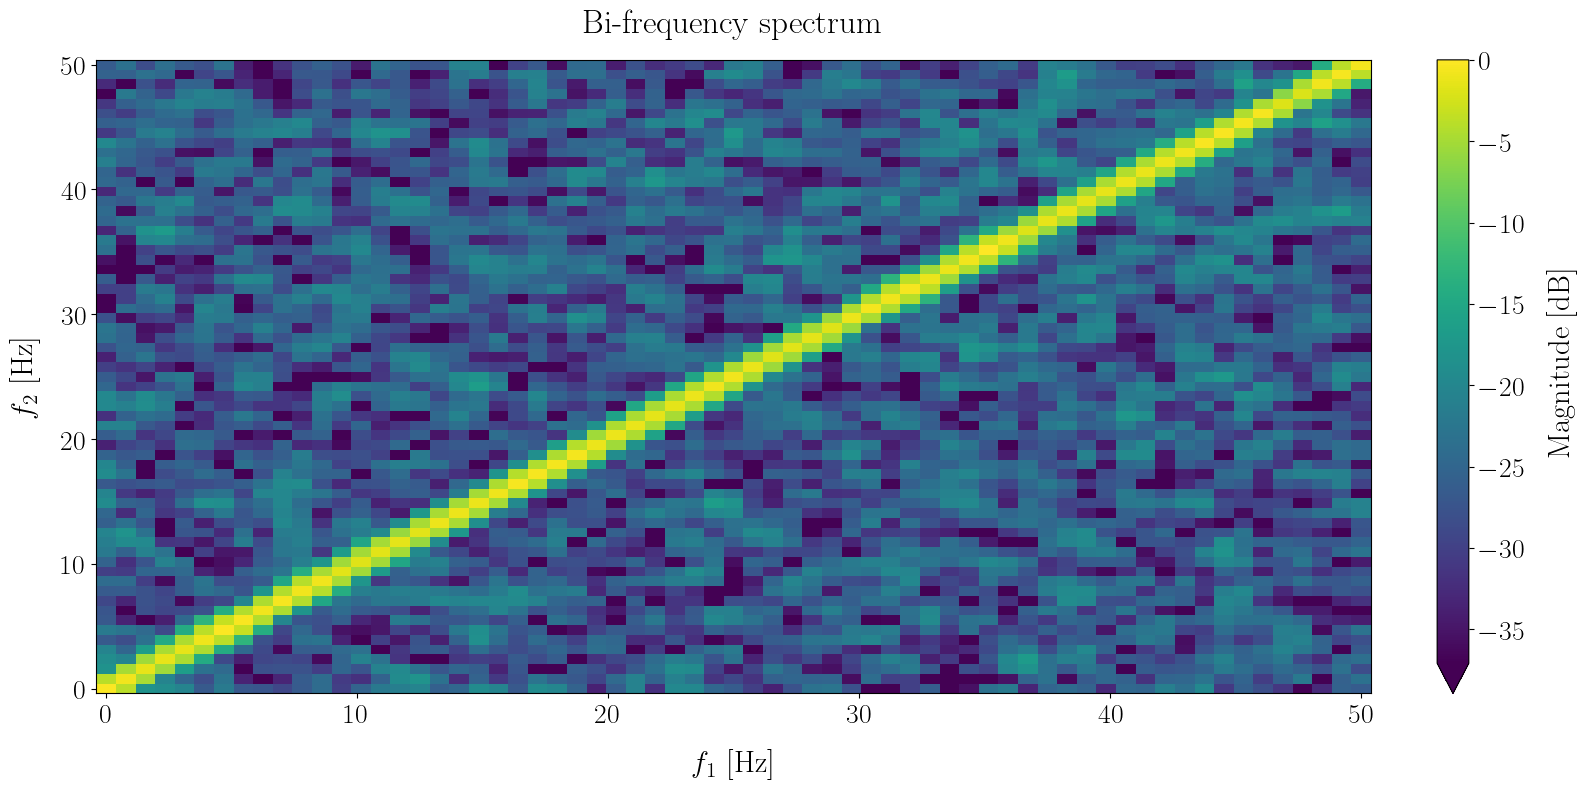

In [17]:
# Bifreq spectrum
from real_data_analysis.signal_processing_utils import get_bifrequency_spectrum

ff, S_f1f2 = get_bifrequency_spectrum(
    s=s,
    fs=src_fs,
    fmin=0,
    fmax=50,
    nperseg=2**7,
    noverlap=2**6,
    plot=True,
    root_img=img_folder_path,
    
)

In [18]:
run_this_section = False

In [19]:
if run_this_section:
    hla_sig_grid, hla_rtf_grid = build_hla_features(
        tf_xr=ds_tf,
        src=src,
        delta_r_rcv=hla_delta_r_rcv,
        rcv_range=rcv_range,
        rcv_depth=rcv_depth,
        n_rcv=hla_nrcv,
        rmin=None,
        rmax=None,
        z_src=src_depth,
    )

    # Get output fs
    z_ts = hla_sig_grid.diff("t").t.values[0]
    z_fs = 1 / z_ts

    # Save HLA features
    hla_sig_grid.attrs = {
        "fs": z_fs,
        "signal_duration": src_signal_duration,
        "source_type": sig_name,
        "antenna": "HLA",
        "delta_r_rcv": hla_delta_r_rcv,
        "n_rcv": hla_nrcv,
        "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
    }
    hla_rtf_grid.attrs = {
        "fs": src_fs,
        "signal_duration": src_signal_duration,
        "antenna": "HLA",
        "delta_r_rcv": hla_delta_r_rcv,
        "n_rcv": hla_nrcv,
        "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
    }
    hla_sig_grid.to_netcdf(hla_sig_fpath)
    hla_rtf_grid.to_netcdf(hla_rtf_fpath)

else:
    # load pre-existing datasets
    hla_sig_grid = xr.open_dataset(hla_sig_fpath)
    hla_rtf_grid = xr.open_dataset(hla_rtf_fpath)

    z_fs = hla_sig_grid.fs

## Plot received signals 

Text(0, 0.5, 'Amplitude')

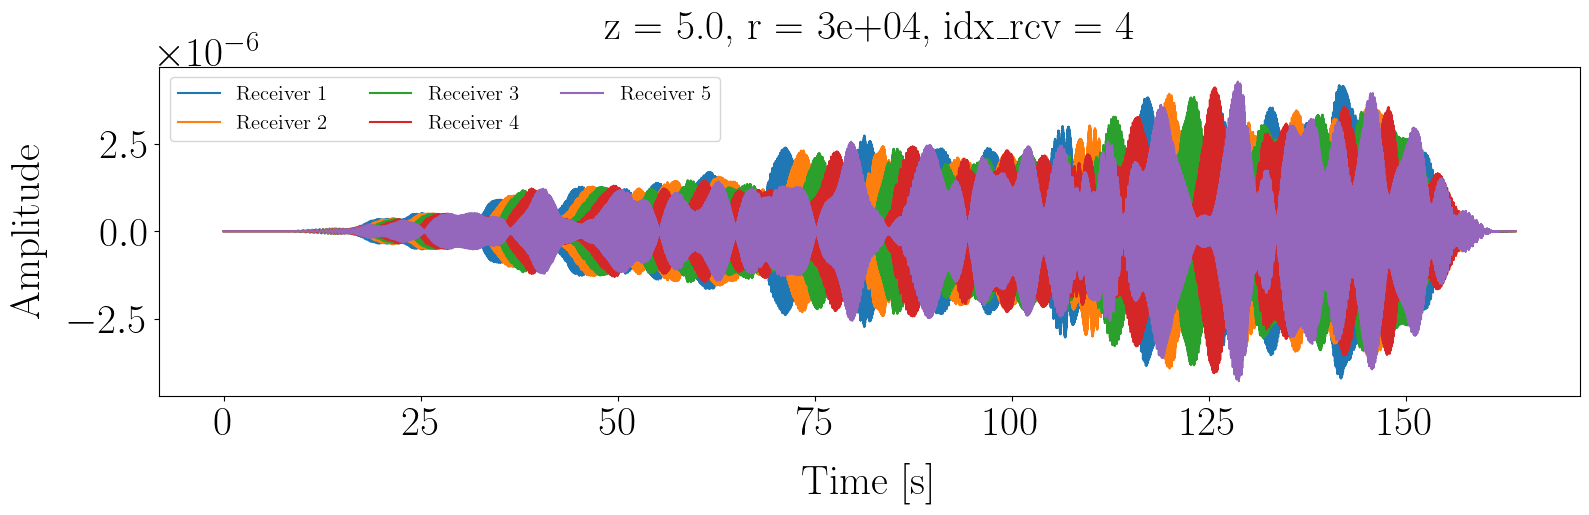

In [20]:
# Visualize signals at each receiver
lfig = LargeFigure()
plt.figure()
for i in range(hla_nrcv):
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=i).plot(label=f"Receiver {i+1}")
# plt.xlim([9.5, 11.5])
plt.legend(ncols=3, fontsize=15)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

In [21]:
# Save HLA features
hla_sig_grid.attrs = {
    "fs": z_fs,
    "signal_duration": src_signal_duration,
    "source_type": sig_name,
    "antenna": "HLA",
    "delta_r_rcv": hla_delta_r_rcv,
    "n_rcv": hla_nrcv,
    "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
}
hla_sig_grid.to_netcdf(hla_sig_fpath)

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\hla_sig_chirp_lfm.nc'

(0.0, 50.0)

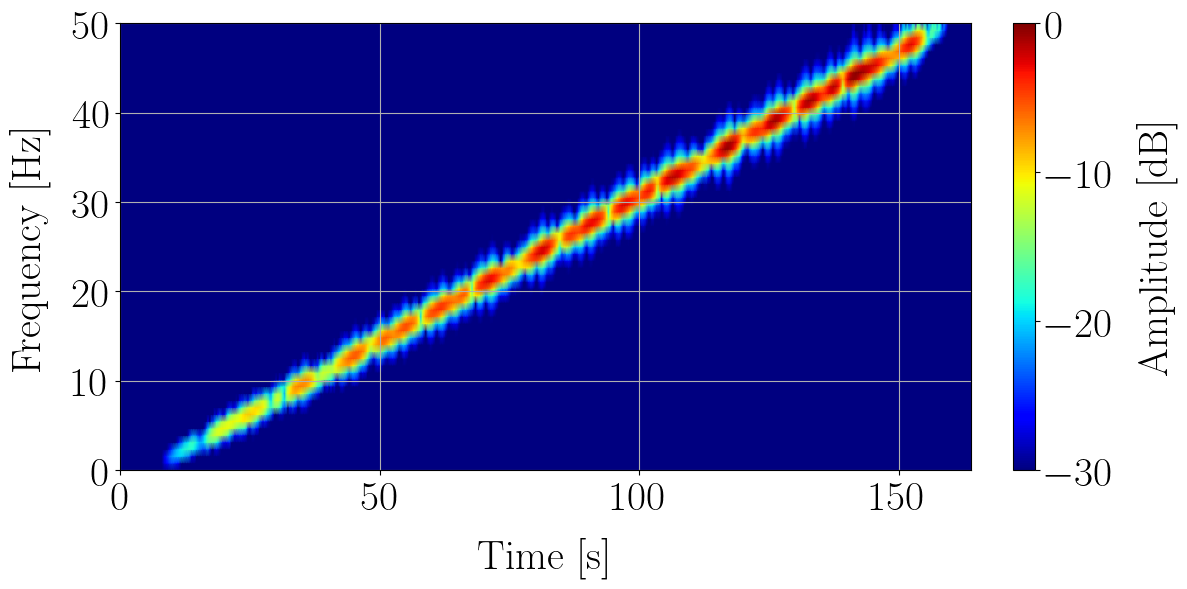

In [22]:
# Derive and plot STFT
window = "hann"
nperseg = 2**7
noverlap = 2**7 * 3//4
ff, tt, Sxx = sp.stft(
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=0),
    fs=z_fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx /= np.max(np.abs(Sxx))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-30, vmax=-0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()
plt.ylim([0, 50])
# plt.xlim([0, 10])

## Plot associated RTF (true) 

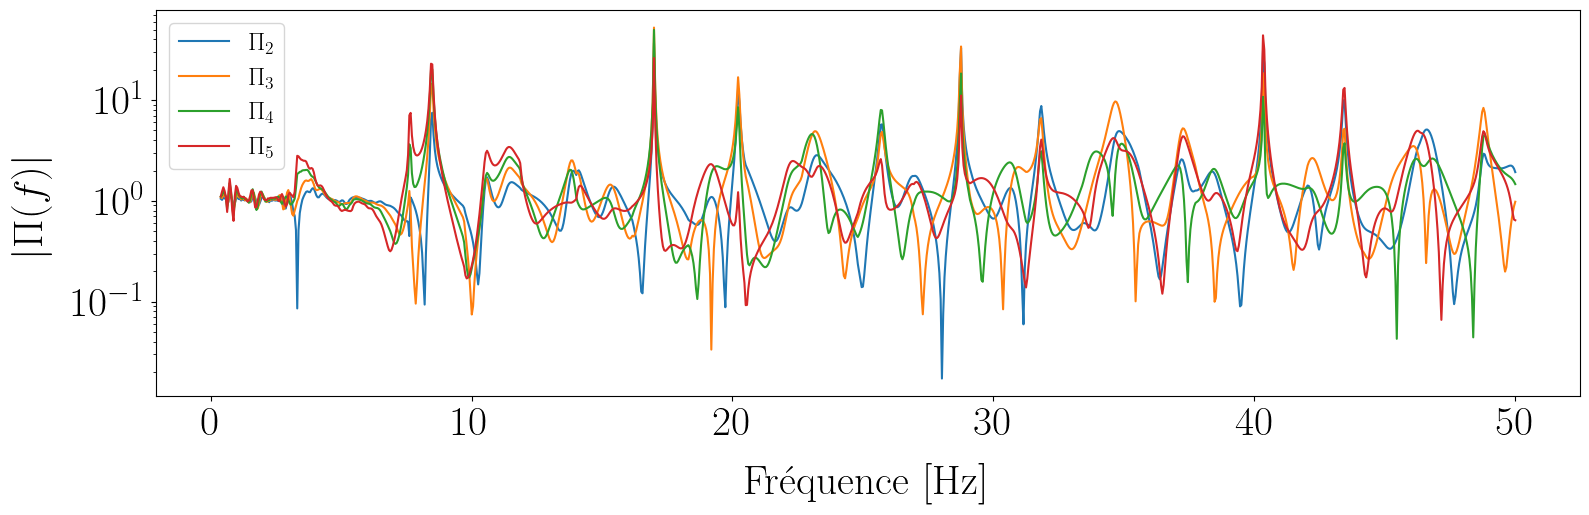

In [23]:
lfig = LargeFigure(language=language, legend_fontsize=18)

hla_rtf_pos = hla_rtf_grid.rtf_real.sel(r=r_plot, z=z_plot) + 1j * hla_rtf_grid.rtf_imag.sel(r=r_plot, z=z_plot)

plt.figure()
nrcv_plot = 4
for i in range(1, nrcv_plot+1):
    # np.abs(hla_rtf_pos.sel(idx_rcv=i)).plot(label=r"$\Pi_{" + str(i) + r"}^{(Kraken)}$"),
    np.abs(hla_rtf_pos.sel(idx_rcv=i)).plot(
        label=r"$\Pi_{" + str(i+1) + r"}$"
    ),


# plt.xscale()
plt.yscale("log")
lfig.f_label.set_axis_label("x")
lfig.rtfmod_label.set_axis_label("y")
plt.legend()
# plt.title(f"Range = {r_plot/1e3} km, Depth = {z_plot} m")
plt.title("")


# Save figure
# Save figure
fpath = os.path.join(img_folder_path, f"rtf_hla_r2345.pdf")
plt.savefig(fpath, dpi=300)

## Cas test 2 : train de LFM

In [24]:
# Extract testcase info
i_tc = 2
sig_name = "lfm_train"
sig_fpath = os.path.join(data_folder_path, f"sig_{sig_name}.nc")
hla_sig_fpath = os.path.join(data_folder_path, f"hla_sig_{sig_name}.nc")
testcase_infos[i_tc] = {"name": sig_name,  
                        "sig_fpath": sig_fpath,
                        "hla_sig_fpath": hla_sig_fpath
                        }

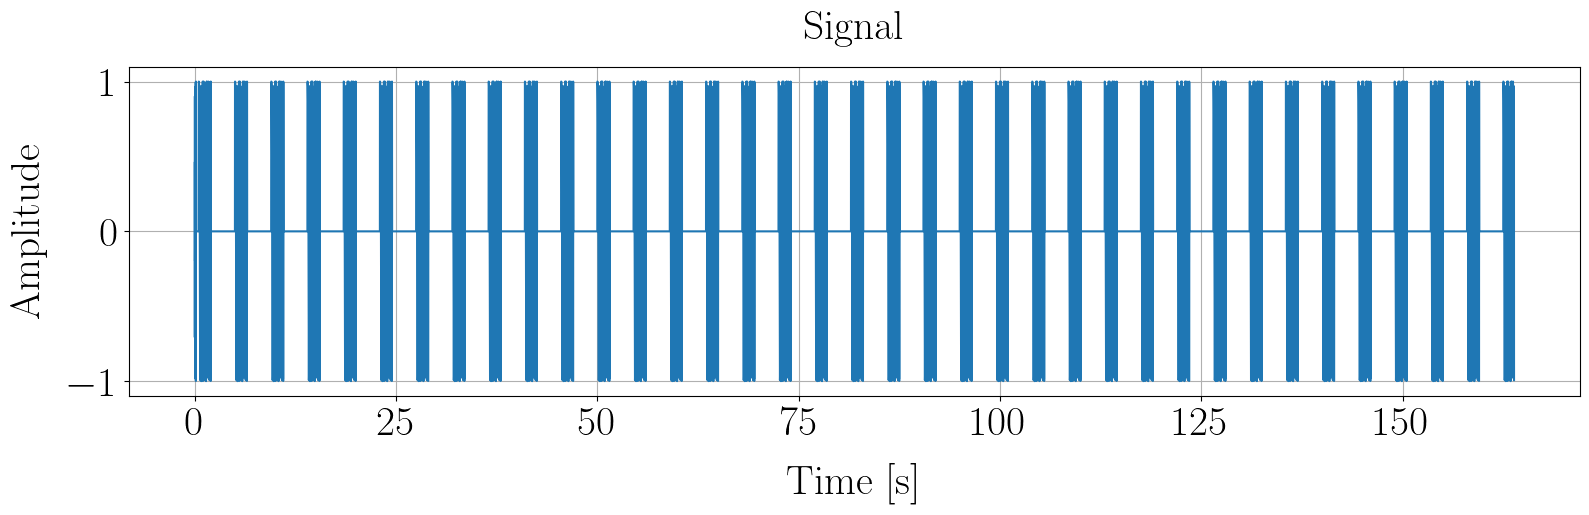

In [25]:
# Define source signal
f0 = 0
f1 = 50
# nchirp = 10
T_chirp = 1.5
interpulse_delay = 3 
s, t = sg.lfm_chirp_train(
    f0,
    f1,
    fs=src_fs,
    T_chirp=T_chirp,
    T=src_signal_duration,
    interpulse_delay=interpulse_delay,
    start_delay=0.5,
)
# t, s = sg.lfm_chirp(f0=f0, f1=f1, fs=src_fs, T=src_signal_duration, phi=0)

s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="Chirp LFM",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

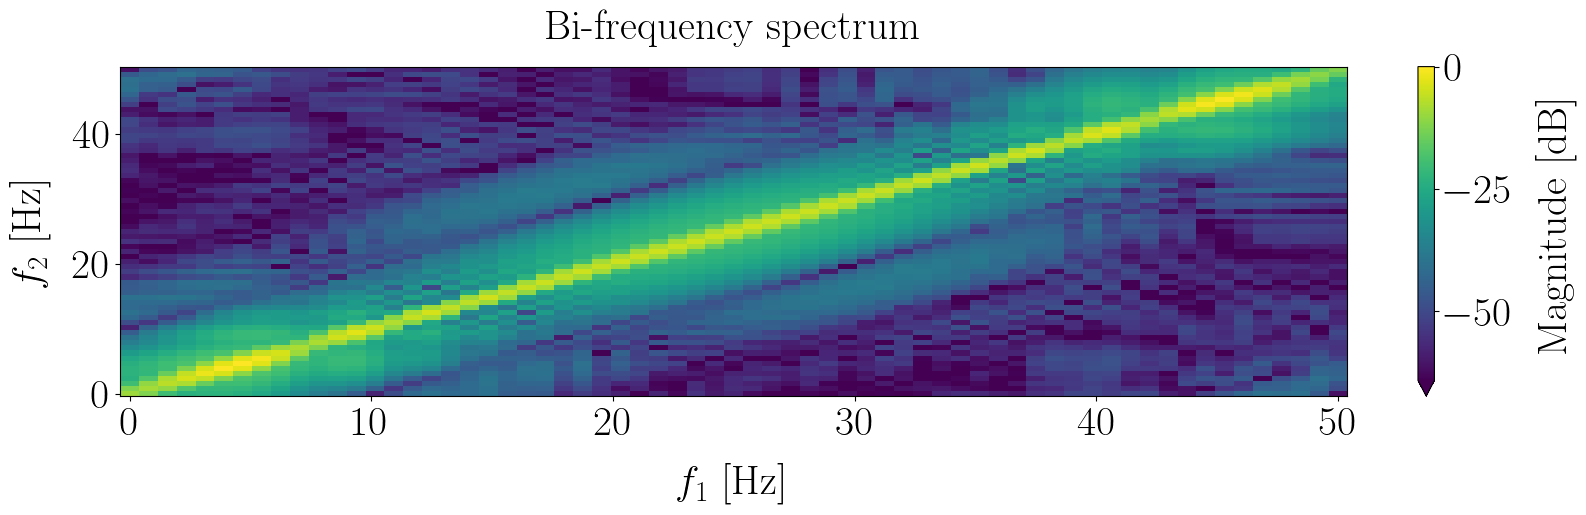

In [26]:
# Bifreq spectrum
ff, S_f1f2 = get_bifrequency_spectrum(
    s=s,
    fs=src_fs,
    fmin=0,
    fmax=50,
    nperseg=2**7,
    noverlap=2**6,
    plot=True,
    root_img=img_folder_path,
)

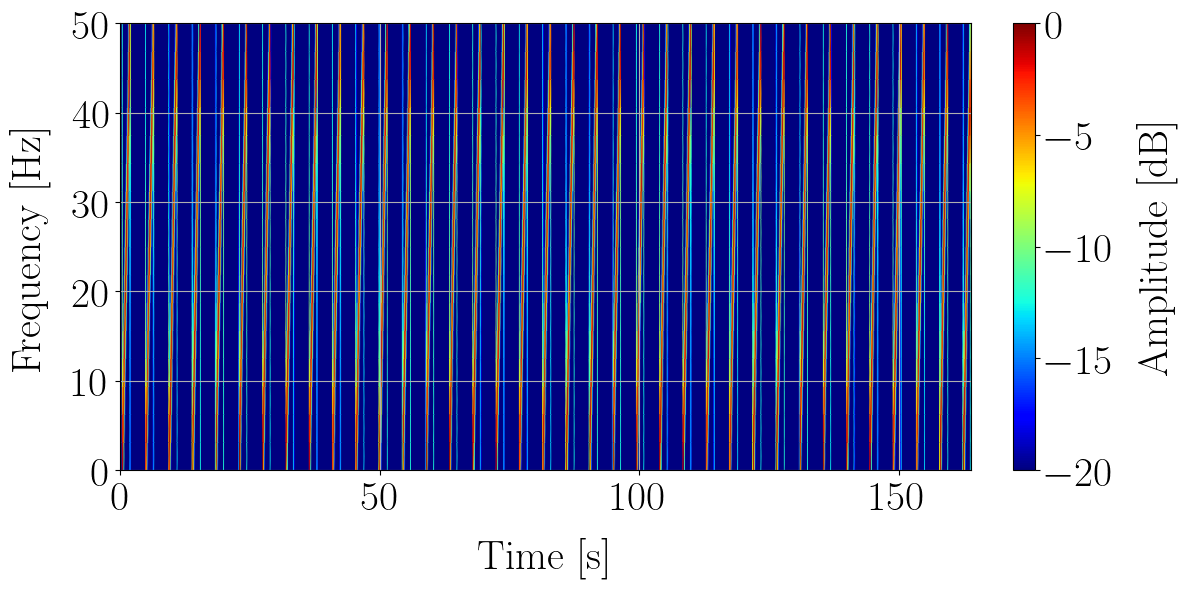

In [27]:
# Derive and plot STFT
window="hann"
nperseg=2**5
noverlap=nperseg //2
ff, tt, Sxx = sp.stft(
    s, fs=src_fs, window=window, nperseg=nperseg, noverlap=noverlap
)

Sxx /= np.max(np.abs(Sxx))
Sxx[Sxx == 0] = 1e-20

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-20, vmax=0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()


In [28]:
# hla_delta_r_rcv = 100  # Receiver range step in meters
hla_sig_grid, _ = build_hla_features(
    tf_xr=ds_tf,
    src=src,
    delta_r_rcv=hla_delta_r_rcv,
    rcv_range=rcv_range,
    rcv_depth=rcv_depth,
    n_rcv=hla_nrcv,
    rmin=None,
    rmax=None,
)

# Get output fs
z_ts = hla_sig_grid.diff("t").t.values[0]
z_fs = 1 / z_ts

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [ ]:
# Visualize signals at each receiver
lfig = LargeFigure()
plt.figure()
for i in range(hla_nrcv):
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=i).plot(label=f"Receiver {i+1}")
# plt.xlim([9.5, 11.5])
plt.legend(ncols=3, fontsize=15)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

In [ ]:
# Save HLA features
hla_sig_grid.attrs = {
    "fs": z_fs,
    "signal_duration": src_signal_duration,
    "source_type": sig_name,
    "antenna": "HLA",
    "delta_r_rcv": hla_delta_r_rcv,
    "n_rcv": hla_nrcv,
    "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
}
hla_sig_grid.to_netcdf(hla_sig_fpath)

In [ ]:
# Derive and plot STFT
window="hann"
nperseg=2**6
noverlap=nperseg // 2
ff, tt, Sxx = sp.stft(
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=2),
    fs=z_fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx /= np.max(np.abs(Sxx))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-20, vmax=-0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()
plt.ylim([0, 50])

# Estimation des vecteurs de RTF

## Load all usefull dataset (to prevent rerunning previous cells)

In [ ]:
# First ensure all datasets are closed 
if "hla_sig_grid" in locals():
    hla_sig_grid.close()
    del hla_sig_grid
if "ds_sig" in locals():
    ds_sig.close()
    del ds_sig

testcase_data = {}
for i_tc in testcase_infos.keys():
    ds = xr.open_dataset(testcase_infos[i_tc]["hla_sig_fpath"])
    testcase_data[i_tc] = ds

In [ ]:
# Load HLA RTF
if "hla_rtf_grid" in locals():
    hla_rtf_grid.close()
    del hla_rtf_grid
ds_hla_rtf = xr.open_dataset(hla_rtf_fpath)

## Define analysis params 

In [ ]:
z_fs = testcase_data[0].attrs["fs"]
cov_snapshot_duration = 3   # Duration of the time window to compute the covariance matrix in seconds (should be greater than the impulse response duration)
cov_snapshot_size = int(cov_snapshot_duration * z_fs)  # Number of samples in the time window to compute the covariance matrix
nperseg = 2 ** int(np.log2(cov_snapshot_size) + 1)
noverlap = nperseg // 2
window = "hann"

print(f"Cov snapshot duration: {cov_snapshot_duration} s")
print(f"Associated nperseg: {nperseg} samples")
print(f"Associated noverlap: {noverlap} samples")


## Initialize RTF estimation tools 

In [ ]:
rtf_estimator = RTFEstimator(
    fs=testcase_data[0].attrs["fs"],
    idx_rcv_ref=idx_rcv_ref,
    nperseg=nperseg,
    noverlap=noverlap,
    window=window,
)

In [ ]:
# Restrict data to the required position
for i_tc in testcase_data.keys():
    testcase_data[i_tc] = testcase_data[i_tc].sel(r=slice(r_hat, r_hat+0.1), z=slice(z_hat, z_hat+0.1))     # slice +0.1 to keep dimensions 

z_fs = testcase_data[0].attrs["fs"]
hla_nrcv = testcase_data[0].attrs["n_rcv"]
# RTF
ds_hla_rtf = ds_hla_rtf.sel(r=slice(r_hat, r_hat+0.1), z=slice(z_hat, z_hat+0.1))  # slice +0.1 to keep dimensions

In [ ]:
rtf_kraken = ds_hla_rtf.rtf_real + 1j * ds_hla_rtf.rtf_imag

## Test at single SNR with differrent source signals 

## Monte carlo simulation for varying source params

In [ ]:
def get_rtf_single_estimate(z_xr, snr, estimators, idx_rcv_ref=0, cpu_time=False):
    # Step 1: generate noise and mix it to the signal
    noise, noise_mix = generate_noise(z_xr.s, snr=snr, idx_rcv_ref=idx_rcv_ref)
    noisy_signal = z_xr.s + noise_mix
    noise_only = noise
    noisy_signal = noisy_signal.squeeze()
    noise_only = noise_only.squeeze()

    # Step 2: estimate rtf
    res = {}
    for e in estimators:
        t0 = time.time()
        if e == "cs":
            f, rtf, _, _ = rtf_estimator.covariance_subtraction(
                noisy_signal=noisy_signal,
                noise_only=noise_only,
                use_first_column=True,
                add_id_x=False,
                add_id_v=False,
            )
        elif e == "cs_evd":

            f, rtf, _, _ = rtf_estimator.covariance_subtraction(
                noisy_signal=noisy_signal,
                noise_only=noise_only,
                use_first_column=False,
                add_id_x=False,
                add_id_v=False,
            )

        elif e == "cw":
            f, rtf, _, _ = rtf_estimator.covariance_whitening(
                noisy_signal=noisy_signal,
                noise_only=noise_only,
                add_id_x=False,
                add_id_v=True,
            )
        t1 = time.time()

        res[e] = {"f":f, "rtf":rtf}
        if cpu_time:
            res[e]["cpu_time"] = t1 - t0

    return res

### Run Monte Carlo

In [ ]:
run_this_section = False
# run_this_section = True

In [37]:
n_mc = 10  # Number of monte carlo simulations per snr
snr = 0

# Delay between two lfm chirps in seconds
delta_flm_delay = 0.1      # Step beteween two flm delay in seconds
flm_delay_min = 0
flm_delay_max = 10
# delta_flm_delay = 0.1  # Step beteween two flm delay in seconds
# flm_delay_min = 0.1
# flm_delay_max = 3
lfm_delays = np.arange(flm_delay_min, flm_delay_max + delta_flm_delay, delta_flm_delay)

# Duration of a single lfm chirp in seconds
delta_lfm_duration = 0.1
lfm_duration_min = 0.1
lfm_duration_max = 10
# delta_lfm_duration = 0.25
# lfm_duration_min = 0.5
# lfm_duration_max = 5
lfm_durations = np.arange(lfm_duration_min, lfm_duration_max + delta_lfm_duration, delta_lfm_duration)

estimators = ["cs_evd"]

# Estimate cpu_time
rtf_avg_cpu_time = 0.05
avg_prep_rtf_cpu_time = 2.25
expected_cpu_time = lfm_delays.size * lfm_durations.size * n_mc * rtf_avg_cpu_time + lfm_delays.size * lfm_durations.size * avg_prep_rtf_cpu_time

cpu_t_h = expected_cpu_time // 3600
cpu_t_m = expected_cpu_time % 3600
cpu_t_s = cpu_t_m % 60
cpu_t_m = cpu_t_m // 60 
print(
    f"Expected cpu time : {expected_cpu_time}s = {cpu_t_h} hours, {cpu_t_m} minutes and {cpu_t_s} seconds"
)

Expected cpu time : 27775.0s = 7.0 hours, 42.0 minutes and 55.0 seconds


In [ ]:
f0 = 0
f1 = 50
start_delay = 3

if run_this_section:

    rtf_estimates = {e: [] for e in estimators}
    i_sim = 0
    # Iterate over lfm delays
    for i, lfm_delay in enumerate(lfm_delays):

        # Iterate over lfm durations
        for k, lfm_duration in enumerate(lfm_durations):

            print(f"Simulation {i_sim+1}/{len(lfm_durations)*len(lfm_delays)}: lfm_delay = {lfm_delay} s, lfm_duration = {lfm_duration} s")
            i_sim += 1

            # t0 = time.time()
            # Create source signal
            interpulse_delay = 3 
            s, t = sg.lfm_chirp_train(
                f0,
                f1,
                fs=src_fs,
                T_chirp=lfm_duration,
                T=src_signal_duration,
                interpulse_delay=lfm_delay,
                start_delay=start_delay,
            )
            s = sg.normalize_sig(s, normalize="max")
            src = AcousticSource(
                signal=s,
                time=t,
                name="LFM Train",
                waveguide_depth=depth,
                window=None,
                nfft=2 ** int(np.log2(s.size) + 1),
            )

            # Propagate signal
            hla_sig_grid, _ = build_hla_features(
                tf_xr=ds_tf,
                src=src,
                delta_r_rcv=hla_delta_r_rcv,
                rcv_range=rcv_range,
                rcv_depth=rcv_depth,
                n_rcv=hla_nrcv,
                rmin=None,
                rmax=None,
            )

            # Get output fs
            z_ts = hla_sig_grid.diff("t").t.values[0]
            z_fs = 1 / z_ts

            # Restrict data to the required position
            z_xr = hla_sig_grid.sel(
                r=slice(r_hat, r_hat + 0.1), z=slice(z_hat, z_hat + 0.1)
            )  # slice +0.1 to keep dimensions
            # cpu_t = time.time() - t0
            # print(f"Pre-rtf calc CPU time : {cpu_t}")

            rtf_xp_i = {e: [] for e in estimators}

            for i_mc in range(n_mc):

                if i_mc % 10 == 0 or i_mc == n_mc - 1:
                    print(f"    MC {i_mc+1}/{n_mc}")

                # Process single estimation
                res = get_rtf_single_estimate(z_xr, snr, estimators, idx_rcv_ref=0)
                if i == 0 and k == 0 and i_mc == 0:
                    f = res[estimators[0]]["f"]
                    # Here we need to select only the frequencies of interest (i.e in the 0 - 50 Hz band)
                    idx_f_in_band = (rtf_kraken.f.min().values <= f) & (
                        f <= rtf_kraken.f.max().values
                    )
                    f_hat = f[idx_f_in_band]

                # Store result
                for e in estimators:
                    rtf_e = res[e]["rtf"][idx_f_in_band, :]
                    rtf_xp_i[e].append(rtf_e)

            # Convert to array and store for current xp
            for e in estimators:
                rtf_estimates[e].append(np.array(rtf_xp_i[e]))


    # Convert to array
    for e in estimators:
        rtf_estimates[e] = np.array(rtf_estimates[e])

    rtf_estimates["f"] = f_hat

## Analyse results 

In [30]:
if run_this_section:

    dist_func = D_hermitian_angle_fast
    ax_f = 2
    ax_rcv = 3
    dist_kwargs = {
        "ax_rcv": ax_rcv,
        "unit": "deg",
        "apply_mean": True,
        "ax_f": ax_f,
    }

    # Get reference rtf
    rtf_ref = rtf_kraken.squeeze()
    # Interp common frequencies (in practice we can just use nearest interpolation since the sampling of the estimated rtf vector is proportional to the rtf_ref sampling) This is due
    # to the fact that we use powers of 2 to define stft snapshot length used for cov estimation
    fmin_comp = 10
    f_comp = rtf_estimates["f"]
    # f_comp = f_comp[f_comp >= fmin_comp]
    rtf_ref = rtf_ref.sel(f=f_comp, method="nearest").values

    thetas = {e: [] for e in estimators}

    expand_rtf_ref = True 
    for e in estimators:
        print(f"Estimator {e}")

        # Get estimated rtf
        rtf_hat = rtf_estimates[e]

        if expand_rtf_ref:
            # Expand to the rtf_hat shape for direct derivation of theta for all snr/mc trial
            rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf_hat.shape, missing_dims_axis=[0, 1])
            expand_rtf_ref = False

        # Derive distance
        theta = dist_func(rtf_ref=rtf_ref_expanded, rtf=rtf_hat, **dist_kwargs)       
        # print(f"  {e}: {np.mean(theta)} +/- {np.std(theta)} {dist_kwargs['unit']}")

        thetas[e] = theta

    # Reshape theta (shape (n_sim, n_mc)) to (n_lfm_delay, n_lfm_duration, n_mc)
    thetas_reshaped = {}
    for e in estimators:
        thetas_reshaped[e] = thetas[e].reshape(
            (len(lfm_delays), len(lfm_durations), n_mc)
            )

In [ ]:
if run_this_section:
    # Store results in dedicated xarray dataset
    data_vars_dict = {
        f"lfm_train_{e}": (["delay", "duration", "mc"], thetas_reshaped[e])
        for e in estimators
    }
    var_names = list(data_vars_dict.keys())

    ds_rtf_perf = xr.Dataset(
        coords=dict(
            delay=lfm_delays,
            duration=lfm_durations,
            mc=np.arange(n_mc),
        ),
        data_vars=data_vars_dict
    )

    # Set attributes to each variable
    for e in estimators:
        name = f"lfm_train_{e}"
        ds_rtf_perf[name].attrs = {
            "description": f"RTF estimation error using {e} estimator for a lfm train source",
            "unit": dist_kwargs["unit"],
            "long_name": f"LFM TRAIN - {e}".upper(),
        }

In [ ]:
fpath = os.path.join(data_folder_path, "rtf_estimation_performance_lfm_train.nc")
if run_this_section:
    # Save dataset 
    ds_rtf_perf.to_netcdf(fpath)

else:
    # Load pre-existing dataset
    ds_rtf_perf = xr.open_dataset(fpath)
    var_names = list(ds_rtf_perf.data_vars.keys())


### Plot results 

#### Theta en fonction des deux paramètres des chirp LFM

In [32]:
nperseg_t = nperseg / z_fs
print(f"Analysis window duration {nperseg_t}s")

Analysis window duration 0.32s


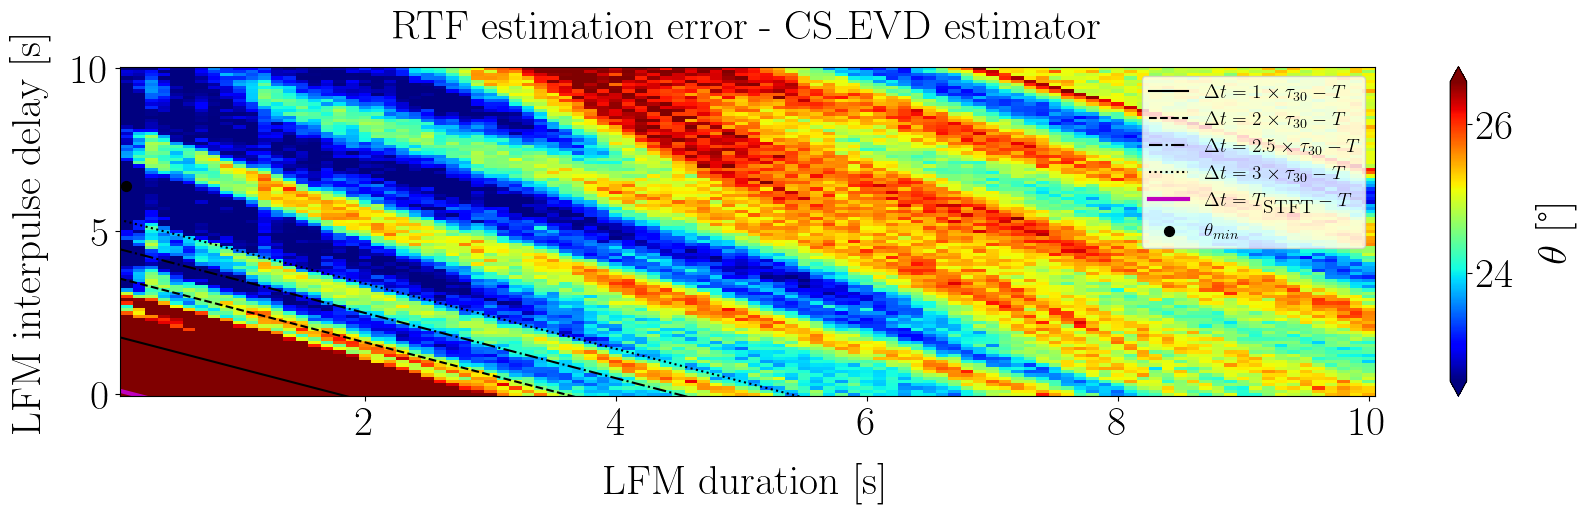

In [38]:
l_fig = LargeFigure(legend_fontsize=14)
estimators = ["cs_evd"]
for e in estimators:
    name = f"lfm_train_{e}"

    plt.figure()

    theta = ds_rtf_perf[name]
    theta_mean = theta.median(dim="mc")

    im = theta_mean.plot(
        x="duration",
        y="delay",
        cmap="jet",
        cbar_kwargs={"label": rf"$\theta$ [°]"},
        vmin=np.percentile(theta_mean, 5),
        vmax=np.percentile(theta_mean, 95),
    )
    # plt.clim([0, 90])
    # plt.colorbar(im, label=rf"$\theta$ [{dist_kwargs['unit']}]")
    plt.title(f"RTF estimation error - {e.upper()} estimator")
    # plt.legend(fontsize=16, ncols=1)
    plt.xlabel("LFM duration [s]")
    plt.ylabel("LFM interpulse delay [s]")

    # Add line define by delay + duration = ir_duration
    x_dur = np.arange(0, np.max(lfm_durations)*1.5, 0.01)
    ir_duration = 1.8
    y_delay_lim = ir_duration - x_dur

    ls = ["-", "--", "-.", ":"]
    mult = [1, 2, 2.5, 3]
    for i, m in enumerate(mult):
        y_delay_lim = ir_duration*m - x_dur
        plt.plot(
            x_dur,
            y_delay_lim,
            "k",
            linestyle=ls[i],
            label=r"$\Delta t = " + str(m) + r"\times \tau_{30} - T$",
        )
    y_delay_lim_aw = nperseg_t*0.5 - x_dur
    plt.plot(
        x_dur,
        y_delay_lim_aw,
        "-m",
        linewidth=3,
        label=r"$\Delta t = T_{\textrm{STFT}} - T$",
    )

    # Add a marker on minimum
    mini = theta_mean.argmin(...)
    min_theta = theta_mean.isel(delay=mini["delay"], duration=mini["duration"])
    plt.scatter(
        min_theta.duration, min_theta.delay, color="k", s=50, label=r"$\theta_{min}$"
    )
    plt.legend()

    # Save figure
    fig_fpath = os.path.join(img_folder_path, f"rtf_estimation_performance_{name}_lfmt_duration_ipd.pdf")
    plt.savefig(fig_fpath, dpi=300)

In [ ]:
# Same figure with std

l_fig = LargeFigure()

for e in estimators:
    name = f"lfm_train_{e}"

    plt.figure()

    theta = ds_rtf_perf[name]
    theta_std = theta.std(dim="mc")

    im = theta_std.plot(
        x="duration",
        y="delay",
        cmap="jet",
        cbar_kwargs={"label": r"$\sigma_{\theta}$" +f" [°]"},
        vmin=np.percentile(theta_std, 1),
        vmax=np.percentile(theta_std, 99),
    )
    # plt.clim([0, 90])
    # plt.colorbar(im, label=rf"$\theta$ [{dist_kwargs['unit']}]")
    plt.title(f"RTF estimation error - {e.upper()} estimator")
    # plt.legend(fontsize=16, ncols=1)
    plt.xlabel("LFM duration [s]")
    plt.ylabel("LFM interpulse delay [s]")

    # Add line define by delay + duration = ir_duration
    x_dur = np.arange(0, np.max(lfm_durations), 0.01)
    ir_duration = 1.8
    y_delay_lim = ir_duration - x_dur

    for i in range(1, 4):
        y_delay_lim = ir_duration * i - x_dur
        plt.plot(x_dur, y_delay_lim, "-k")

    # Add a marker on minimum
    mini = theta_std.argmin(...)
    min_theta = theta_std.isel(delay=mini["delay"], duration=mini["duration"])
    plt.scatter(min_theta.delay, min_theta.duration)
    # Save figure
    fig_fpath = os.path.join(img_folder_path, f"rtf_estimation_performance_{name}_std.pdf")
    plt.savefig(fig_fpath, dpi=300)

## Compare optimal lfm train to long lfm 

ici comparer le train de lfm avec le couple de paramètres optimaux au cas d'un lfm long 